# Laboratorio 6 - Task 1


## 1. Q-Learning tabular y DQN

LunarLanderContinuous-v2 usa dos acciones continuas: la fuerza de cada propulsor. Esto significa que hay infinitas acciones posibles. Q-Learning tabular no sirve porque tendría que guardar un valor $Q(s,a)$ para cada estado y cada acción posible.

Tanto Q-Learning como DQN necesitan calcular $\arg\max_a Q(s,a)$ para elegir la mejor acción. Esto es fácil cuando hay pocas acciones discretas, pero no cuando $a$ es un vector continuo. DQN representa una política indirecta: primero calcula valores Q y luego elige el mayor. Para este caso es más natural representar directamente una política continua que genere acciones.

## 2. Gradiente de la política Gaussiana

La política es una Gaussiana cuya media $\mu_\theta(s)$ sale de una red neuronal. Con $\sigma$ fija:

$$\ln\pi_\theta(a\mid s)=-\frac{d}{2}\ln(2\pi\sigma^2)-\frac{\lVert a-\mu_\theta(s)\rVert^2}{2\sigma^2}.$$

El primer término no depende de $\theta$. La parte que sí depende de $\theta$ es la media de la red. Por eso:

$$\nabla_\theta\ln\pi_\theta(a\mid s)=\frac{1}{\sigma^2}(\nabla_\theta\mu_\theta(s))^T(a-\mu_\theta(s)).$$

En simple: se compara la acción tomada con la media que propuso la red y se ajustan los pesos de la red en esa dirección.

## 3. REINFORCE con línea base vs. Actor-Critic

REINFORCE con línea base usa $\hat A_t=G_t-b(S_t)$: el retorno completo menos una estimación del valor del estado. Si la línea base solo depende del estado, no agrega sesgo. Sin embargo, el retorno completo tiene mucha varianza porque depende de todo lo que ocurre hasta terminar el episodio.

Actor-Critic suele usar $\hat A_t=R_{t+1}+\gamma V_w(S_{t+1})-V_w(S_t)$. Tiene menos varianza porque aprende con información inmediata, pero puede tener sesgo si el Critic estima mal el valor de los estados.

Esperamos que Actor-Critic converja más rápido. En LunarLander hay muchas decisiones por episodio y el Critic da una señal de aprendizaje más frecuente. REINFORCE es más simple, pero suele aprender de forma más inestable.

## 4. Suavidad de acciones en el exoesqueleto

Se puede castigar en la recompensa que la acción cambie demasiado entre un instante y otro:

$$r'_t=r_t-\lambda\lVert a_t-a_{t-1}\rVert^2.$$

También conviene limitar la fuerza máxima y la rapidez con que puede cambiar. La política puede recibir la acción anterior y generar solo un cambio pequeño: $a_t=a_{t-1}+\Delta a_t$.

La elección no cambia: Actor-Critic sigue siendo una mejor opción inicial porque normalmente necesita menos datos. Aun así, en un sistema real se deben usar límites de seguridad además de la recompensa.

## 5. Implementación desde cero: REINFORCE y Actor-Critic

La siguiente implementación usa PyTorch únicamente para definir las redes y calcular gradientes automáticamente. La política es una Gaussiana continua: su media sale de una red MLP con dos capas ocultas de 64 neuronas y ReLU, seguida de `tanh`; `log_std` es un parámetro aprendible independiente del estado, inicializado para que `sigma = 0.5`.

In [1]:
import math
from io import BytesIO
import random

import matplotlib.pyplot as plt
from IPython.display import Image, display
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.distributions import Normal

try:
    import gymnasium as gym
except ImportError:
    import gym

SEED = 42
N_EPISODES = 1000
GAMMA = 0.99
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
ENV_CANDIDATES = ('LunarLanderContinuous-v2', 'LunarLanderContinuous-v3')


def set_seed(seed):
    """Fija todas las fuentes de aleatoriedad usadas por el experimento."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def make_env(render_mode=None):
    """Crea v2 y usa v3 solo si v2 no está disponible en la instalación."""
    kwargs = {} if render_mode is None else {'render_mode': render_mode}
    last_error = None
    for env_id in ENV_CANDIDATES:
        try:
            return gym.make(env_id, **kwargs)
        except Exception as error:
            last_error = error
    raise RuntimeError(
        'No se pudo crear LunarLanderContinuous. Instala gymnasium[box2d].'
    ) from last_error


def reset_env(env, seed=None):
    """Normaliza reset() para Gymnasium y versiones antiguas de Gym."""
    try:
        result = env.reset(seed=seed) if seed is not None else env.reset()
    except TypeError:
        if seed is not None and hasattr(env, 'seed'):
            env.seed(seed)
        result = env.reset()
    return result[0] if isinstance(result, tuple) else result


def step_env(env, action):
    """Normaliza step() a (estado, recompensa, terminado, truncado, info)."""
    result = env.step(action)
    if len(result) == 5:
        next_state, reward, terminated, truncated, info = result
    else:
        next_state, reward, done, info = result
        terminated, truncated = bool(done), False
    return next_state, float(reward), bool(terminated), bool(truncated), info


def state_tensor(state):
    tensor = torch.as_tensor(np.asarray(state), dtype=torch.float32, device=DEVICE)
    return tensor.unsqueeze(0) if tensor.ndim == 1 else tensor


def clamp_log_std(module):
    """Evita escalas numéricamente inestables sin dejar de aprender sigma."""
    with torch.no_grad():
        module.log_std.clamp_(math.log(0.05), math.log(2.0))


def gradient_norm_from_tensors(gradients):
    squared_norm = sum(
        gradient.detach().pow(2).sum()
        for gradient in gradients
        if gradient is not None
    )
    return float(torch.sqrt(squared_norm).detach().cpu()) if squared_norm.numel() else 0.0


def display_figure(figure):
    """Embebe una figura PNG para que el notebook conserve la visualizacion."""
    buffer = BytesIO()
    figure.savefig(buffer, format='png', dpi=120, bbox_inches='tight')
    display(Image(data=buffer.getvalue(), format='png'))
    plt.close(figure)


### 5.1 Redes de política, línea base y Actor-Critic

`GaussianPolicy` y `ValueNetwork` son redes separadas para REINFORCE. En `ActorCritic`, `shared` se usa tanto para la cabeza de la media como para la cabeza escalar del valor; por eso el Critic comparte el cuerpo con el Actor.

In [2]:
class GaussianPolicy(nn.Module):
    """Politica Gaussiana continua para REINFORCE."""

    def __init__(self, state_dim, action_dim):
        super().__init__()
        self.shared = nn.Sequential(
            nn.Linear(state_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
        )
        self.mean_head = nn.Linear(64, action_dim)
        self.log_std = nn.Parameter(
            torch.full((action_dim,), math.log(0.5), dtype=torch.float32)
        )

    def forward(self, states):
        if states.ndim == 1:
            states = states.unsqueeze(0)
        mean = torch.tanh(self.mean_head(self.shared(states)))
        std = self.log_std.exp().expand_as(mean)
        return mean, std

    def distribution(self, states):
        mean, std = self(states)
        return Normal(mean, std)

    def sample(self, states):
        distribution = self.distribution(states)
        action = distribution.sample().clamp(-1.0, 1.0)
        log_prob = distribution.log_prob(action).sum(dim=-1)
        entropy = distribution.entropy().sum(dim=-1)
        return action, log_prob, entropy

    def evaluate(self, states, actions):
        distribution = self.distribution(states)
        log_prob = distribution.log_prob(actions).sum(dim=-1)
        entropy = distribution.entropy().sum(dim=-1)
        return log_prob, entropy

    def mean_action(self, states):
        return self(states)[0]


class ValueNetwork(nn.Module):
    """Linea base V_pi(s) independiente de la politica."""

    def __init__(self, state_dim):
        super().__init__()
        self.body = nn.Sequential(
            nn.Linear(state_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
        )
        self.value_head = nn.Linear(64, 1)

    def forward(self, states):
        if states.ndim == 1:
            states = states.unsqueeze(0)
        return self.value_head(self.body(states))


class ActorCritic(nn.Module):
    """Actor y Critic con un cuerpo MLP compartido."""

    def __init__(self, state_dim, action_dim):
        super().__init__()
        self.shared = nn.Sequential(
            nn.Linear(state_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
        )
        self.mean_head = nn.Linear(64, action_dim)
        self.value_head = nn.Linear(64, 1)
        self.log_std = nn.Parameter(
            torch.full((action_dim,), math.log(0.5), dtype=torch.float32)
        )

    def forward(self, states):
        if states.ndim == 1:
            states = states.unsqueeze(0)
        features = self.shared(states)
        mean = torch.tanh(self.mean_head(features))
        std = self.log_std.exp().expand_as(mean)
        value = self.value_head(features)
        return mean, std, value

    def distribution(self, states):
        mean, std, _ = self(states)
        return Normal(mean, std)

    def sample(self, states):
        distribution = self.distribution(states)
        action = distribution.sample().clamp(-1.0, 1.0)
        log_prob = distribution.log_prob(action).sum(dim=-1)
        entropy = distribution.entropy().sum(dim=-1)
        return action, log_prob, entropy

    def value(self, states):
        return self(states)[2]

    def mean_action(self, states):
        return self(states)[0]

    def actor_parameters(self):
        return list(self.shared.parameters()) + list(self.mean_head.parameters()) + [self.log_std]


### 5.2 Utilidades y algoritmos

REINFORCE calcula el retorno completo `G_t`, actualiza una línea base separada con MSE y usa `G_t - V(s_t)` como ventaja. Actor-Critic actualiza en cada transición usando el objetivo TD(0), `r + gamma V(s')`, y comparte los gradientes del cuerpo entre las dos cabezas.

In [3]:
def discounted_returns(rewards, gamma=GAMMA):
    returns = []
    running_return = 0.0
    for reward in reversed(rewards):
        running_return = float(reward) + gamma * running_return
        returns.append(running_return)
    returns.reverse()
    return torch.as_tensor(returns, dtype=torch.float32, device=DEVICE)


def moving_average(values, window=20):
    values = np.asarray(values, dtype=np.float32)
    if len(values) < window:
        return np.array([], dtype=np.float32)
    kernel = np.ones(window, dtype=np.float32) / window
    return np.convolve(values, kernel, mode='valid')


def train_reinforce(
    n_episodes=N_EPISODES,
    seed=SEED,
    gamma=GAMMA,
    actor_lr=3e-4,
    baseline_lr=1e-3,
):  
    """Entrena REINFORCE con una linea base V(s) separada."""
    set_seed(seed)
    env = make_env()
    state_dim = int(np.prod(env.observation_space.shape))
    action_dim = int(np.prod(env.action_space.shape))
    policy = GaussianPolicy(state_dim, action_dim).to(DEVICE)
    baseline = ValueNetwork(state_dim).to(DEVICE)
    actor_optimizer = torch.optim.Adam(policy.parameters(), lr=actor_lr)
    baseline_optimizer = torch.optim.Adam(baseline.parameters(), lr=baseline_lr)
    metrics = {
        'episode_rewards': [],
        'actor_grad_norms': [],
        'policy_entropies': [],
    }

    try:
        env.action_space.seed(seed)
        for episode in range(n_episodes):
            state = reset_env(env, seed=seed + episode)
            states, actions, rewards = [], [], []
            done = False

            while not done:
                states.append(np.asarray(state, dtype=np.float32))
                state_t = state_tensor(state)
                action, _, _ = policy.sample(state_t)
                action_np = action.squeeze(0).detach().cpu().numpy()
                next_state, reward, terminated, truncated, _ = step_env(env, action_np)
                actions.append(action_np.astype(np.float32))
                rewards.append(reward)
                state = next_state
                done = terminated or truncated

            states_t = torch.as_tensor(np.asarray(states), dtype=torch.float32, device=DEVICE)
            actions_t = torch.as_tensor(np.asarray(actions), dtype=torch.float32, device=DEVICE)
            returns_t = discounted_returns(rewards, gamma)
            values_t = baseline(states_t).squeeze(-1)
            advantages_t = returns_t - values_t.detach()
            log_probs_t, entropies_t = policy.evaluate(states_t, actions_t)

            actor_loss = -(log_probs_t * advantages_t).mean()
            actor_optimizer.zero_grad(set_to_none=True)
            actor_loss.backward()
            actor_grad_norm = gradient_norm_from_tensors(
                [parameter.grad for parameter in policy.parameters()]
            )
            torch.nn.utils.clip_grad_norm_(policy.parameters(), max_norm=5.0)
            actor_optimizer.step()
            clamp_log_std(policy)

            baseline_optimizer.zero_grad(set_to_none=True)
            baseline_loss = F.mse_loss(baseline(states_t).squeeze(-1), returns_t)
            baseline_loss.backward()
            torch.nn.utils.clip_grad_norm_(baseline.parameters(), max_norm=5.0)
            baseline_optimizer.step()

            metrics['episode_rewards'].append(float(np.sum(rewards)))
            metrics['actor_grad_norms'].append(actor_grad_norm)
            metrics['policy_entropies'].append(float(entropies_t.mean().detach().cpu()))

            if (episode + 1) % 100 == 0:
                recent = np.mean(metrics['episode_rewards'][-20:])
                print(f'REINFORCE episodio {episode + 1:4d}/{n_episodes}: media(20) = {recent:8.2f}')
    finally:
        env.close()

    return {'policy': policy, 'baseline': baseline, 'metrics': metrics}


def train_actor_critic(
    n_episodes=N_EPISODES,
    seed=SEED,
    gamma=GAMMA,
    learning_rate=3e-4,
):  
    """Entrena Actor-Critic con actualizaciones TD(0) en cada paso."""
    set_seed(seed)
    env = make_env()
    state_dim = int(np.prod(env.observation_space.shape))
    action_dim = int(np.prod(env.action_space.shape))
    model = ActorCritic(state_dim, action_dim).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    metrics = {
        'episode_rewards': [],
        'actor_grad_norms': [],
        'policy_entropies': [],
    }

    try:
        env.action_space.seed(seed)
        for episode in range(n_episodes):
            state = reset_env(env, seed=seed + episode)
            episode_reward = 0.0
            episode_grad_norms, episode_entropies = [], []
            done = False

            while not done:
                state_t = state_tensor(state)
                action, log_prob, entropy = model.sample(state_t)
                action_np = action.squeeze(0).detach().cpu().numpy()
                next_state, reward, terminated, truncated, _ = step_env(env, action_np)
                done = terminated or truncated

                with torch.no_grad():
                    next_value = torch.zeros((), device=DEVICE)
                    if not done:
                        next_value = model.value(state_tensor(next_state)).squeeze()
                _, _, value = model(state_t)
                td_target = torch.as_tensor(reward, dtype=torch.float32, device=DEVICE)
                td_target = td_target + gamma * (1.0 - float(done)) * next_value
                advantage = td_target - value.squeeze(-1)

                actor_loss = -(log_prob.squeeze(-1) * advantage.detach())
                critic_loss = 0.5 * advantage.pow(2).mean()
                actor_gradients = torch.autograd.grad(
                    actor_loss, model.actor_parameters(), retain_graph=True, allow_unused=True
                )
                episode_grad_norms.append(gradient_norm_from_tensors(actor_gradients))
                episode_entropies.append(float(entropy.mean().detach().cpu()))

                optimizer.zero_grad(set_to_none=True)
                (actor_loss + critic_loss).backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
                optimizer.step()
                clamp_log_std(model)

                episode_reward += reward
                state = next_state

            metrics['episode_rewards'].append(float(episode_reward))
            metrics['actor_grad_norms'].append(float(np.mean(episode_grad_norms)))
            metrics['policy_entropies'].append(float(np.mean(episode_entropies)))

            if (episode + 1) % 100 == 0:
                recent = np.mean(metrics['episode_rewards'][-20:])
                print(f'Actor-Critic episodio {episode + 1:4d}/{n_episodes}: media(20) = {recent:8.2f}')
    finally:
        env.close()

    return {'policy': model, 'metrics': metrics}


### 5.3 Experimento reproducible

Cada función vuelve a fijar `SEED = 42` y usa `seed + episodio` al reiniciar el entorno. Así ambos algoritmos reciben la misma secuencia de semillas del entorno y parten de inicializaciones reproducibles.

In [4]:
reinforce_results = train_reinforce(n_episodes=N_EPISODES, seed=SEED)
actor_critic_results = train_actor_critic(n_episodes=N_EPISODES, seed=SEED)

print(f'Dispositivo: {DEVICE}')
print(f'Episodios por algoritmo: {N_EPISODES}')
print(f'REINFORCE recompensa final media(20): {np.mean(reinforce_results["metrics"]["episode_rewards"][-20:]):.2f}')
print(f'Actor-Critic recompensa final media(20): {np.mean(actor_critic_results["metrics"]["episode_rewards"][-20:]):.2f}')


/private/var/folders/zb/2jhfc6nd3fngdf8nnhhlg_hm0000gn/T/lab6-rl.XXXXXX.3PMzzytprZ/venv/lib/python3.14/site-packages/gymnasium/envs/registration.py:513: DeprecationWarning: WARN: The environment LunarLanderContinuous-v2 is out of date. You should consider upgrading to version `v3`.
  logger.deprecation(


REINFORCE episodio  100/1000: media(20) =  -366.21


REINFORCE episodio  200/1000: media(20) =  -672.12


REINFORCE episodio  300/1000: media(20) =  -912.66


REINFORCE episodio  400/1000: media(20) =  -840.84


...

Actor-Critic episodio  600/1000: media(20) =  -666.85


Actor-Critic episodio  700/1000: media(20) =  -667.18


Actor-Critic episodio  800/1000: media(20) =  -683.29


Actor-Critic episodio  900/1000: media(20) =  -704.91


Actor-Critic episodio 1000/1000: media(20) =  -723.43
Dispositivo: cpu
Episodios por algoritmo: 1000
REINFORCE recompensa final media(20): -1017.81
Actor-Critic recompensa final media(20): -723.43


### 5.4 Métricas y visualizaciones

Las curvas muestran los datos por episodio y, cuando corresponde, una media móvil de 20 episodios. Se mantiene la misma codificación de color para cada algoritmo en las tres gráficas comparativas.

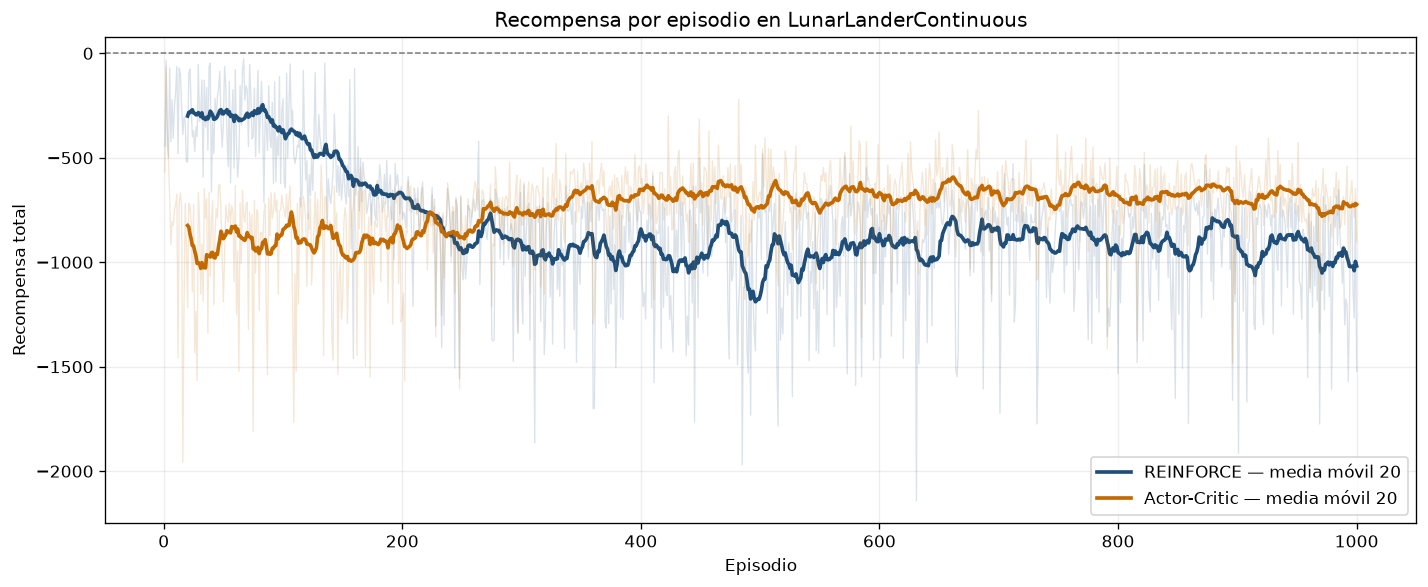

In [5]:
COLORS = {'REINFORCE': '#1f4e79', 'Actor-Critic': '#c26a00'}
RESULTS = {'REINFORCE': reinforce_results, 'Actor-Critic': actor_critic_results}
WINDOW = 20

figure = plt.figure(figsize=(12, 5))
for name, result in RESULTS.items():
    rewards = np.asarray(result['metrics']['episode_rewards'])
    episodes = np.arange(1, len(rewards) + 1)
    plt.plot(episodes, rewards, color=COLORS[name], alpha=0.16, linewidth=0.8)
    smooth = moving_average(rewards, WINDOW)
    plt.plot(episodes[WINDOW - 1:], smooth, color=COLORS[name], linewidth=2.2, label=f'{name} — media móvil 20')
plt.axhline(0, color='#777777', linewidth=0.9, linestyle='--')
plt.title('Recompensa por episodio en LunarLanderContinuous')
plt.xlabel('Episodio')
plt.ylabel('Recompensa total')
plt.legend()
plt.grid(alpha=0.22)
plt.tight_layout()
display_figure(figure)


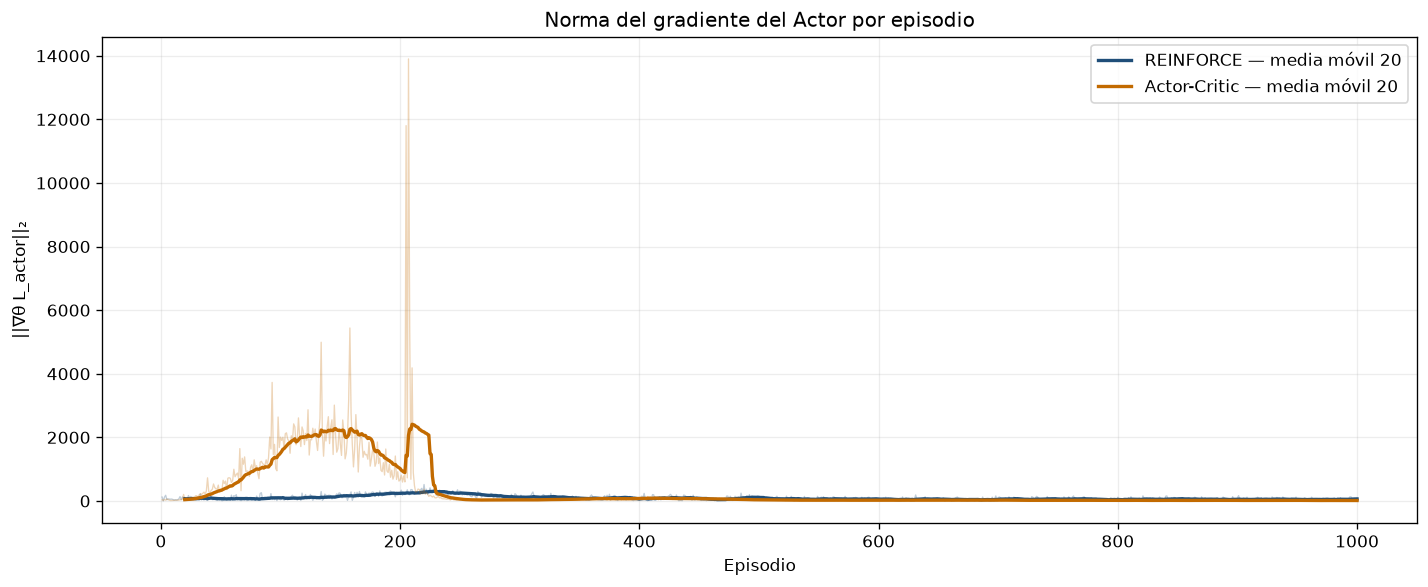

In [6]:
figure = plt.figure(figsize=(12, 5))
for name, result in RESULTS.items():
    norms = np.asarray(result['metrics']['actor_grad_norms'])
    plt.plot(np.arange(1, len(norms) + 1), norms, color=COLORS[name], alpha=0.28, linewidth=0.8)
    smooth = moving_average(norms, WINDOW)
    plt.plot(np.arange(WINDOW, len(norms) + 1), smooth, color=COLORS[name], linewidth=2.0, label=f'{name} — media móvil 20')
plt.title('Norma del gradiente del Actor por episodio')
plt.xlabel('Episodio')
plt.ylabel(r'||∇θ L_actor||₂')
plt.legend()
plt.grid(alpha=0.22)
plt.tight_layout()
display_figure(figure)


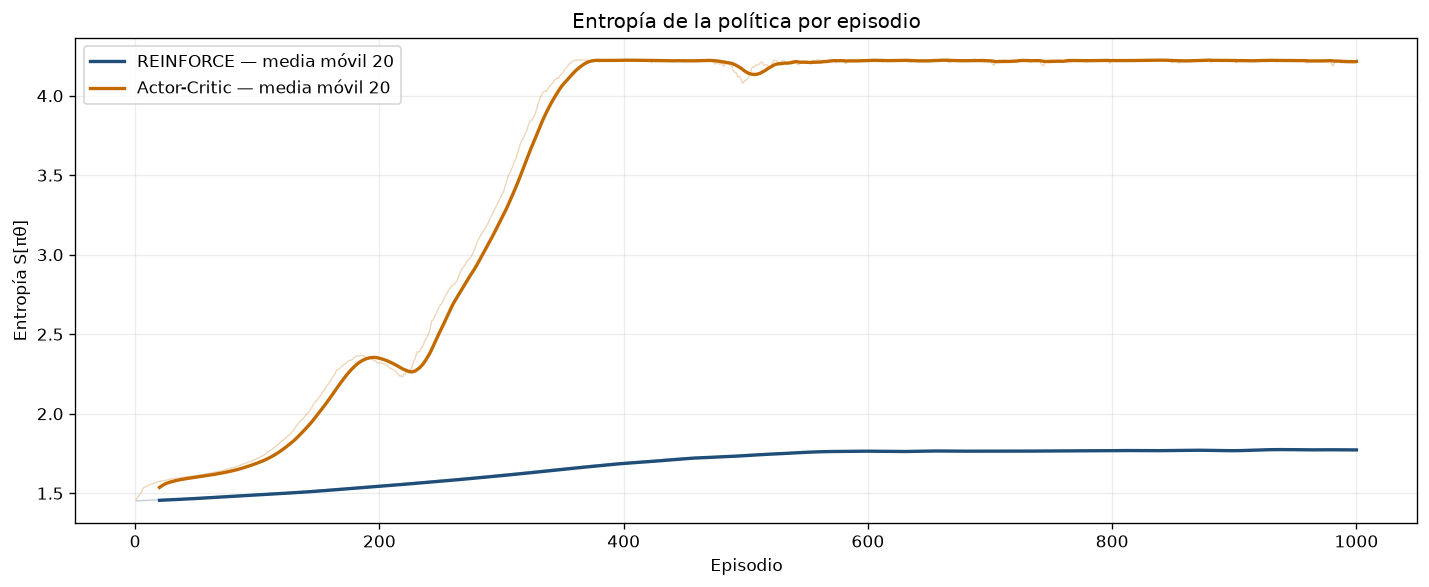

In [7]:
figure = plt.figure(figsize=(12, 5))
for name, result in RESULTS.items():
    entropies = np.asarray(result['metrics']['policy_entropies'])
    plt.plot(np.arange(1, len(entropies) + 1), entropies, color=COLORS[name], alpha=0.28, linewidth=0.8)
    smooth = moving_average(entropies, WINDOW)
    plt.plot(np.arange(WINDOW, len(entropies) + 1), smooth, color=COLORS[name], linewidth=2.0, label=f'{name} — media móvil 20')
plt.title('Entropía de la política por episodio')
plt.xlabel('Episodio')
plt.ylabel('Entropía S[πθ]')
plt.legend()
plt.grid(alpha=0.22)
plt.tight_layout()
display_figure(figure)


### 5.5 Visualización de una política aprendida con `env.render()`

Se ejecuta una trayectoria determinista usando la media `μθ(s)` de cada política y se capturan los frames RGB devueltos por `env.render()`.

REINFORCE: 77 frames, recompensa = -832.85
Actor-Critic: 77 frames, recompensa = -833.43


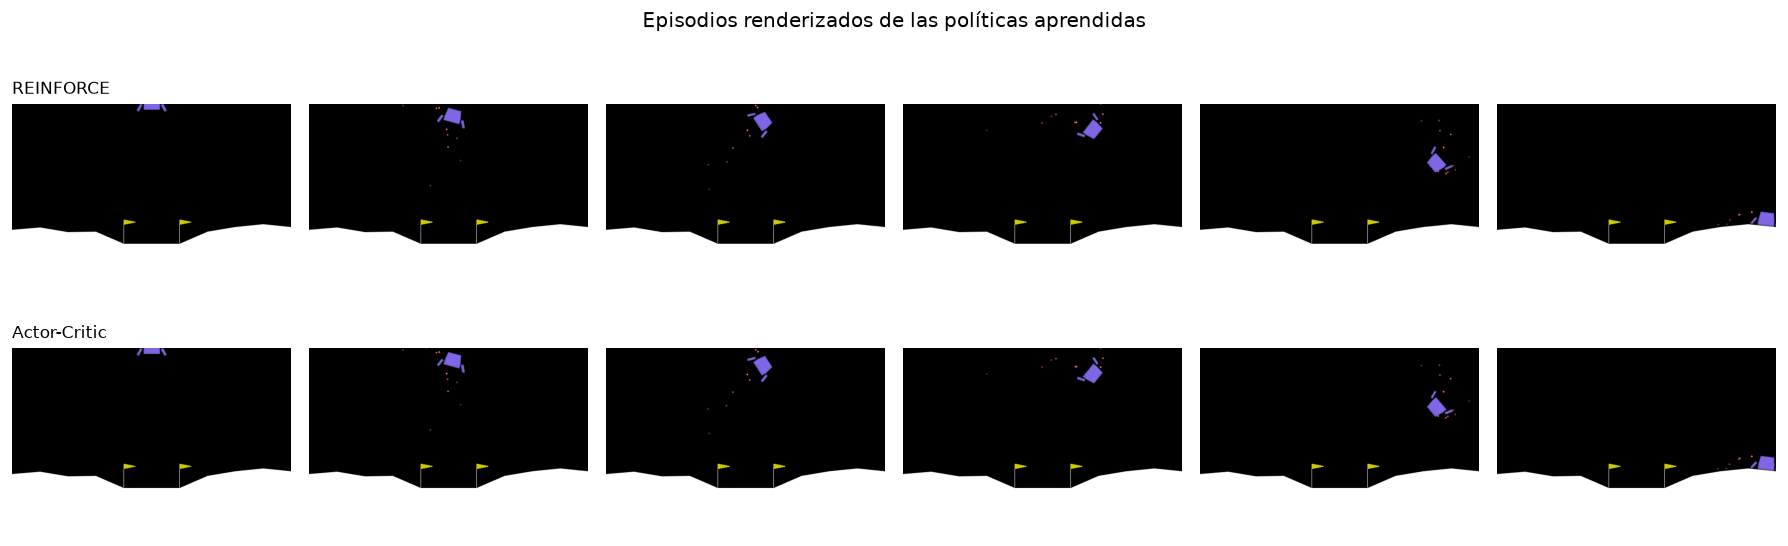

In [8]:
def rollout_for_render(policy, seed=SEED, max_steps=1000):
    env = make_env(render_mode='rgb_array')
    frames, rewards = [], []
    try:
        state = reset_env(env, seed=seed)
        done = False
        for _ in range(max_steps):
            frame = env.render()
            if frame is not None:
                frames.append(np.asarray(frame))
            with torch.no_grad():
                action = policy.mean_action(state_tensor(state)).squeeze(0).cpu().numpy()
            next_state, reward, terminated, truncated, _ = step_env(env, action)
            rewards.append(reward)
            state = next_state
            done = terminated or truncated
            if done:
                final_frame = env.render()
                if final_frame is not None:
                    frames.append(np.asarray(final_frame))
                break
    finally:
        env.close()
    return frames, float(np.sum(rewards))


rendered_episodes = {}
for name, result in RESULTS.items():
    frames, reward = rollout_for_render(result['policy'], seed=SEED + 10000)
    rendered_episodes[name] = {'frames': frames, 'reward': reward}
    print(f'{name}: {len(frames)} frames, recompensa = {reward:.2f}')

figure = plt.figure(figsize=(15, 5))
n_columns = 6
for row, (name, data) in enumerate(rendered_episodes.items()):
    frames = data['frames']
    if not frames:
        raise RuntimeError('env.render() no devolvió frames RGB para esta política.')
    indices = np.linspace(0, len(frames) - 1, n_columns, dtype=int)
    for column, frame_index in enumerate(indices):
        axis = plt.subplot(len(rendered_episodes), n_columns, row * n_columns + column + 1)
        axis.imshow(frames[frame_index])
        axis.axis('off')
        if column == 0:
            axis.set_title(name, loc='left', fontsize=10)
        axis.set_xlabel(f't={frame_index}', fontsize=8)
plt.suptitle('Episodios renderizados de las políticas aprendidas')
plt.tight_layout()
display_figure(figure)
